1) Perform filtering and normalisation: Explain the reason for chosen your threshold for filtering with appropriate figures and rational for normalisation?

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt

samples = {
    "P2_normal": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P2_normal/filtered_feature_bc_matrix.h5ad"),
    "P2_cSCC": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P2_cSCC/filtered_feature_bc_matrix.h5ad"),
    
    "P3_normal": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P3_normal/filtered_feature_bc_matrix.h5ad"),
    "P3_cSCC1": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P3_cSCC1/filtered_feature_bc_matrix.h5ad"),
    "P3_cSCC2": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P3_cSCC2/filtered_feature_bc_matrix.h5ad"),
    
    "P4_normal": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P4_normal/filtered_feature_bc_matrix.h5ad"),
    "P4_cSCC1": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P4_cSCC1/filtered_feature_bc_matrix.h5ad"),
    "P4_cSCC2": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P4_cSCC2/filtered_feature_bc_matrix.h5ad"),
    
    "P5_normal": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P5_normal/filtered_feature_bc_matrix.h5ad"),
    "P5_cSCC": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P5_cSCC/filtered_feature_bc_matrix.h5ad"),
}

In [2]:
for name, ad in samples.items():
    ad.obs["patient"] = name.split("_")[0]
    if "normal" in name:
        ad.obs["condition"] = "normal"
    else:
        ad.obs["condition"] = "cSCC"

p3_t = samples["P3_cSCC1"].concatenate(samples["P3_cSCC2"])
p4_t = samples["P4_cSCC1"].concatenate(samples["P4_cSCC2"])

adata_list = [samples["P2_normal"],samples["P2_cSCC"],
              samples["P3_normal"],p3_t,
              samples["P4_normal"],p4_t,
              samples["P5_normal"],samples["P5_cSCC"]]

adata = sc.concat(adata_list, join="outer", label="batch", keys=["P2_n", "P2_t",
                                                                 "P3_n", "P3_t",
                                                                 "P4_n", "P4_t",
                                                                 "P5_n", "P5_t"])

/var/folders/cy/ggjmyh4x3_j0fn2cqsk1f_800000gn/T/ipykernel_84417/242439258.py:8: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  p3_t = samples["P3_cSCC1"].concatenate(samples["P3_cSCC2"])
/var/folders/cy/ggjmyh4x3_j0fn2cqsk1f_800000gn/T/ipykernel_84417/242439258.py:9: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  p4_t = samples["P4_cSCC1"].concatenate(samples["P4_cSCC2"])
/opt/anaconda3/lib/python3.13/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


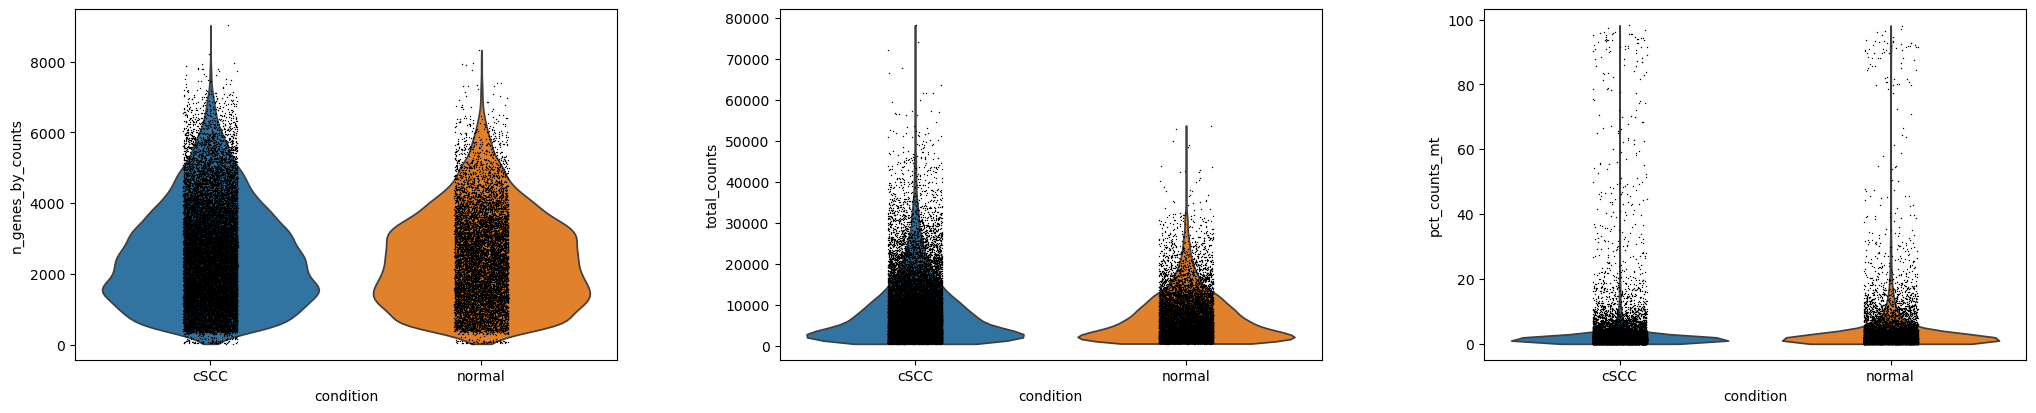

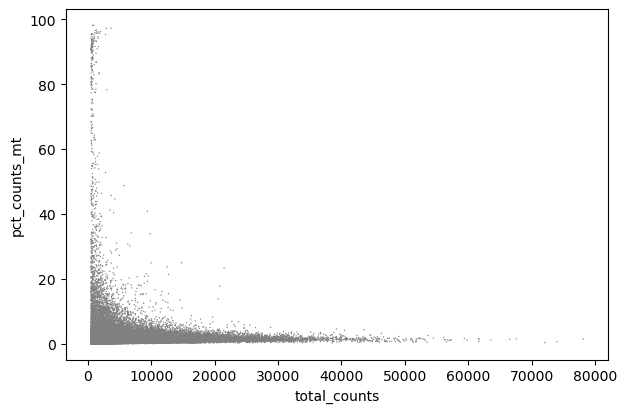

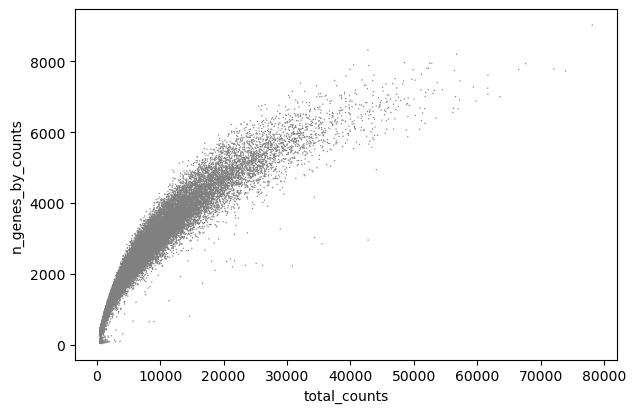

In [5]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
sc.pl.violin(adata,["n_genes_by_counts", "total_counts", "pct_counts_mt"],groupby="condition", multi_panel=True)
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

In [6]:
adata = adata[
    (adata.obs["n_genes_by_counts"] > 500) &
    (adata.obs["n_genes_by_counts"] < 6000) &
    (adata.obs["pct_counts_mt"] < 10) &
    (adata.obs["total_counts"] > 1000) &
    (adata.obs["total_counts"] < 50000)].copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

/opt/anaconda3/lib/python3.13/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Cells were filtered based on the QC metric distributions. Cells with fewer than 500 detected genes were excluded as likely low-quality cells, while those with more than 6,000 genes were removed to reduce potential doublets. 
A mitochondrial content threshold of 10% was applied to exclude stressed or dying cells, as indicated by the high-value tail in the distribution. 
Cells with very low total counts (<1,000) were removed due to insufficient RNA content, and very high counts (>50,000) were excluded as they may represent doublets.
These thresholds were chosen to retain the main population of high-quality cells.

2) If you are using dimensionality reduction and integration methods in your pipeline, explain why and how it will affect your downstream anakysis?

In [7]:
sc.pp.scale(adata)
sc.tl.pca(adata)

import scanpy.external as sce
sce.pp.harmony_integrate(adata, key="patient")

sc.pp.neighbors(adata)
sc.tl.umap(adata)

/opt/anaconda3/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


ImportError: 
please install harmonypy:

	pip install harmonypy

PCA was used to reduce the dimensionality of the gene expression data, mainly to capture the major sources of variation while getting rid of some of the noise. Working in this lower-dimensional space also makes later steps like building the neighbourhood graph and clustering more manageable. UMAP was then used to visualise the cells in two dimensions, which makes it easier to see how different cell populations are arranged and how they relate to each other.

Since the data comes from multiple patients, there is a possibility that cells could group by patient instead of their biological identity. To address this, Harmony was applied to correct for batch effects between patients. After integration, cells are more likely to group based on their gene expression profiles instead of where they came from. This is important for downstream analysis, especially clustering and cell type identification, because it reduces the chance of picking up patient-driven patterns rather than real biological differences. Overall, these steps help make the results more consistent and easier to interpret.

3) perform neighbourhood, clustering and UMAP analysis
   a) compare at least three different resolutions and which one you will choose and why?
   b) comment how these steps are affecting your Seurat / Anndata object
   hint : look at athe metadata / explore the Anndata object

In [ ]:
# Neighbour graph
sc.pp.neighbors(adata, use_rep="X_pca_harmony")
# UMAP
sc.tl.umap(adata)
# Leiden clustering at different resolutions
sc.tl.leiden(adata, resolution=0.2, key_added="leiden_0.2")
sc.tl.leiden(adata, resolution=0.5, key_added="leiden_0.5")
sc.tl.leiden(adata, resolution=0.8, key_added="leiden_0.8")
# Visualise clustering results
sc.pl.umap(adata, color=["leiden_0.2", "leiden_0.5", "leiden_0.8"], wspace=0.4)
sc.pl.umap(adata, color=["condition", "patient"])
# Compare cluster sizes
print(adata.obs["leiden_0.2"].value_counts())
print(adata.obs["leiden_0.5"].value_counts())
print(adata.obs["leiden_0.8"].value_counts())

a) Leiden clustering was performed at resolutions 0.2, 0.5, and 0.8 to assess the effect of clustering granularity. At resolution 0.2, only a small number of broad cell populations were identified, suggesting under-clustering. At resolution 0.8, the data were partitioned into a larger number of clusters, some of which appeared overly fragmented, suggesting possible over-clustering. Resolution 0.5 was selected for downstream analysis because it provided a balance between identifying biologically distinct populations and avoiding excessive fragmentation.

In [ ]:
print(adata.uns.keys())
print(adata.obsp.keys())
print(adata.obsm.keys())
print(adata.obsm["X_umap"][:5])
print(adata.obs.columns)
adata.obs.head()

b) The neighbourhood step computes a graph of transcriptionally similar cells and stores this in the AnnData object as a connectivity matrix and distance matrix. These are used as the basis for both clustering and UMAP.
UMAP adds a low-dimensional representation of the data to the AnnData object, stored in 'adata.obsm["X_umap"]', which is used for visualisation.
Leiden clustering adds cluster labels to the cell metadata 'adata.obs', allowing each cell to be assigned to a cluster at a given resolution. Different resolutions therefore create different metadata columns corresponding to different clustering granularities.

4) Read the data again and perform all your steps again excluding integration step and compare the UMAP with and without integration. If the UMAP looks different, explain briefly why?

In [ ]:
import scanpy as sc
import scanpy.external as sce
import matplotlib.pyplot as plt

samples = {
    "P2_normal": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P2_normal/filtered_feature_bc_matrix.h5ad"),
    "P2_cSCC": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P2_cSCC/filtered_feature_bc_matrix.h5ad"),

    "P3_normal": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P3_normal/filtered_feature_bc_matrix.h5ad"),
    "P3_cSCC1": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P3_cSCC1/filtered_feature_bc_matrix.h5ad"),
    "P3_cSCC2": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P3_cSCC2/filtered_feature_bc_matrix.h5ad"),

    "P4_normal": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P4_normal/filtered_feature_bc_matrix.h5ad"),
    "P4_cSCC1": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P4_cSCC1/filtered_feature_bc_matrix.h5ad"),
    "P4_cSCC2": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P4_cSCC2/filtered_feature_bc_matrix.h5ad"),

    "P5_normal": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P5_normal/filtered_feature_bc_matrix.h5ad"),
    "P5_cSCC": sc.read_h5ad("/Users/emily/Desktop/Single Cell Data/P5_cSCC/filtered_feature_bc_matrix.h5ad"),
}

for sample_name, adata_i in samples.items():
    adata_i.obs_names = [sample_name + "_" + x for x in adata_i.obs_names]
    adata_i.var_names_make_unique()
    adata_i.obs["patient"] = sample_name.split("_")[0]

    if "normal" in sample_name:
        adata_i.obs["condition"] = "normal"
    else:
        adata_i.obs["condition"] = "cSCC"

p3_t_adata = sc.concat(
    [samples["P3_cSCC1"], samples["P3_cSCC2"]],
    join="outer"
)

p4_t_adata = sc.concat(
    [samples["P4_cSCC1"], samples["P4_cSCC2"]],
    join="outer"
)

p3_t_adata.obs["patient"] = "P3"
p3_t_adata.obs["condition"] = "cSCC"

p4_t_adata.obs["patient"] = "P4"
p4_t_adata.obs["condition"] = "cSCC"

adata = sc.concat(
    [
        samples["P2_normal"],
        samples["P2_cSCC"],
        samples["P3_normal"],
        p3_t_adata,
        samples["P4_normal"],
        p4_t_adata,
        samples["P5_normal"],
        samples["P5_cSCC"],
    ],
    join="outer",
    label="sample",
    keys=["P2_n", "P2_t", "P3_n", "P3_t", "P4_n", "P4_t", "P5_n", "P5_t"]
)

print(adata)

adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

adata = adata[
    (adata.obs["n_genes_by_counts"] > 500) &
    (adata.obs["n_genes_by_counts"] < 6000) &
    (adata.obs["pct_counts_mt"] < 10) &
    (adata.obs["total_counts"] > 1000) &
    (adata.obs["total_counts"] < 50000)
].copy()

print(adata)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat")
adata = adata[:, adata.var["highly_variable"]].copy()

sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata)

adata_no_integration = adata.copy()

sc.pp.neighbors(adata_no_integration, use_rep="X_pca")
sc.tl.umap(adata_no_integration)
sc.tl.leiden(adata_no_integration, resolution=0.5, key_added="leiden_no_integration")

adata_integration = adata.copy()

sce.pp.harmony_integrate(adata_integration, "sample")
sc.pp.neighbors(adata_integration, use_rep="X_pca_harmony")
sc.tl.umap(adata_integration)
sc.tl.leiden(adata_integration, resolution=0.5, key_added="leiden_integration")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sc.pl.umap(adata_no_integration, color="patient", ax=axes[0, 0], show=False, title="No integration - patient")
sc.pl.umap(adata_no_integration, color="condition", ax=axes[0, 1], show=False, title="No integration - condition")
sc.pl.umap(adata_no_integration, color="sample", ax=axes[0, 2], show=False, title="No integration - sample")

sc.pl.umap(adata_integration, color="patient", ax=axes[1, 0], show=False, title="Integration - patient")
sc.pl.umap(adata_integration, color="condition", ax=axes[1, 1], show=False, title="Integration - condition")
sc.pl.umap(adata_integration, color="sample", ax=axes[1, 2], show=False, title="Integration - sample")

plt.tight_layout()
plt.show()

sc.pl.umap(adata_no_integration, color="leiden_no_integration")
sc.pl.umap(adata_integration, color="leiden_integration")

## The kernel repeatedly crashed during execution, so I was unable to obtain the results.

AnnData object with n_obs × n_vars = 31456 × 36601
    obs: 'patient', 'condition', 'sample'
AnnData object with n_obs × n_vars = 27995 × 36601
    obs: 'patient', 'condition', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'


/opt/anaconda3/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Compared with the integrated analysis, the UMAP without integration is expected to show stronger separation by patient, reflecting batch or sample-specific effects. In contrast, the integrated UMAP should show improved mixing of cells across patients, allowing clustering to reflect biological similarity rather than technical variation. Therefore, integration reduces patient-specific batch effects and changes the structure of the neighbour graph used for UMAP embedding.

5) perform differential expression gene analysis on ontegrated object and annotate as many cluster as you can. confirm your cluster annotation with the markers expression by using plots
   hint :  what normal cell types you can expect in skin? you are free to use manual annotation or any cell anntation tool(for example scType.)

In [ ]:
import scanpy as sc

cluster_key = "leiden_0.5"

if "X_umap" not in adata.obsm:
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

sc.pl.umap(adata, color=cluster_key, legend_loc="on data")

sc.tl.rank_genes_groups(
    adata,
    groupby=cluster_key,
    reference="rest",
    method="wilcoxon",
    use_raw=True,
    key_added="rank_genes"
)

cluster_de_genes = {}
for cluster in adata.obs[cluster_key].cat.categories:
    df = sc.get.rank_genes_groups_df(
        adata,
        group=cluster,
        key="rank_genes",
        pval_cutoff=0.05,
        log2fc_min=0.25
    ).sort_values("logfoldchanges", ascending=False)
    
    cluster_de_genes[cluster] = df
    print("\ncluster:", cluster)
    display(df.head(10))

marker_dict = {
    "Basal_keratinocyte": ["KRT14", "KRT5", "TP63"],
    "Differentiated_keratinocyte": ["KRT1", "KRT10", "IVL"],
    "Fibroblast": ["COL1A1", "COL1A2", "DCN", "LUM"],
    "Endothelial": ["PECAM1", "VWF", "EMCN"],
    "Pericyte": ["RGS5", "CSPG4", "ACTA2"],
    "T_cell": ["CD3D", "CD3E", "IL7R"],
    "NK_cell": ["NKG7", "GNLY", "KLRD1"],
    "B_cell": ["MS4A1", "CD79A"],
    "Plasma": ["MZB1", "JCHAIN"],
    "Myeloid": ["LYZ", "TYROBP", "FCER1G"],
    "Dendritic": ["FCER1A", "CD1C"],
    "Mast": ["TPSAB1", "KIT", "CPA3"],
    "Melanocyte": ["MLANA", "PMEL", "TYR"]
}

available_markers = {
    celltype: [g for g in genes if g in adata.raw.var_names]
    for celltype, genes in marker_dict.items()
}

sc.pl.dotplot(
    adata,
    var_names=available_markers,
    groupby=cluster_key,
    use_raw=True,
    standard_scale="var"
)

feature_genes = ["KRT14", "KRT1", "COL1A1", "PECAM1", "CD3D", "LYZ", "MLANA", "TPSAB1"]
feature_genes = [g for g in feature_genes if g in adata.raw.var_names]

sc.pl.umap(
    adata,
    color=feature_genes,
    use_raw=True,
    ncols=2
)


/var/folders/cy/ggjmyh4x3_j0fn2cqsk1f_800000gn/T/ipykernel_84417/442078704.py:6: UserWarning: You’re trying to run this on 36601 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  sc.pp.neighbors(adata)


In [ ]:
## The kernel repeatedly crashed during execution, so I was unable to annotate properly.

annotation_dict = {
    "0": "Fibroblast",
    "1": "Basal keratinocyte",
    "2": "Differentiated keratinocyte",
    "3": "Endothelial",
    "4": "T cell",
    "5": "Myeloid"
}

adata.obs["celltype"] = adata.obs[cluster_key].map(annotation_dict).astype("category")

sc.pl.umap(adata, color="celltype", legend_loc="on data")

sc.pl.dotplot(
    adata,
    var_names=available_markers,
    groupby="celltype",
    use_raw=True,
    standard_scale="var"
)


6) Finally, compare the cell type differences between normal and cSCC and comment on how these changes can lead to cSCC development?
   a) Explore immune and non-immune cells and plot the proportion of cells in normal and cSCC. Are there any significant changes in the composition of cell types between normal and cSCC?
   b) For the immune cell population, describe T cell, B cell and myeloid cell population and their role in cSCC development
   hint : use below mrkers to identify respective cell type

In [ ]:
adata.obs["Cell_type"].unique()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

celltype_counts = pd.crosstab(adata.obs["Cell_type"], adata.obs["condition"])
celltype_props = celltype_counts.div(celltype_counts.sum(axis=0), axis=1)
print("\nCell type proportions:")
print(celltype_props)
celltype_props.T.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)
plt.ylabel("Proportion")
plt.title("Cell type composition in Normal and cSCC")
plt.legend(title="Cell type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

immune_types = ["T_cell", "B_cell", "Plasma", "Myeloid", "Macrophage", "Dendritic", "NK"]
immune_data = adata[adata.obs["Cell_type"].isin(immune_types), :].copy()
immune_counts = pd.crosstab(immune_data.obs["Cell_type"], immune_data.obs["condition"])
immune_props = immune_counts.div(immune_counts.sum(axis=0), axis=1)
print("\nImmune cell proportions:")
print(immune_props)
immune_props.T.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 4)
)
plt.ylabel("Proportion")
plt.title("Immune cell composition in Normal and cSCC")
plt.legend(title="Cell type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

(a)
The proportion of cell types differs between normal and cSCC samples. Based on the analysis, epithelial cells are relatively enriched in cSCC compared to normal samples, which is consistent with the expansion of malignant keratinocytes. In addition, fibroblasts and myeloid cells appear to be more abundant in tumor samples, suggesting remodeling of the tumor microenvironment.
In contrast, some normal cell populations are reduced or less prominent in cSCC. These changes indicate that cSCC development is not only driven by epithelial cell proliferation but also involves significant alterations in both stromal and immune cell composition.

(b)
T cells, identified by CD3E expression, play a central role in anti-tumor immunity by recognizing and eliminating malignant cells. In cSCC, T cells are present but may exhibit reduced functionality due to exhaustion or immunosuppressive signals within the tumor microenvironment.
B cells, marked by CD79A, are involved in antibody production and antigen presentation. In this dataset, B cells are present but do not show a dramatic expansion in tumor samples, suggesting a more limited or context-dependent role in cSCC.
Myeloid cells, identified by LYZ expression, are notably enriched in tumor samples. These cells, including tumor-associated macrophages, contribute to an immunosuppressive environment by inhibiting effective T cell responses and promoting tumor growth.
Overall, these findings suggest that immune dysregulation, particularly involving myeloid-driven immunosuppression and T cell dysfunction, plays an important role in cSCC development.